## 1️. Adatok betöltése

In [32]:
import pandas as pd

In [33]:
train = pd.read_csv('./titanic/train.csv')
test = pd.read_csv('./titanic/test.csv')

In [34]:
print(train.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [35]:
print(train.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


## 2. Hiányzó és kiugró értékek kezelése

In [36]:
import seaborn as sb
import matplotlib.pyplot as plt

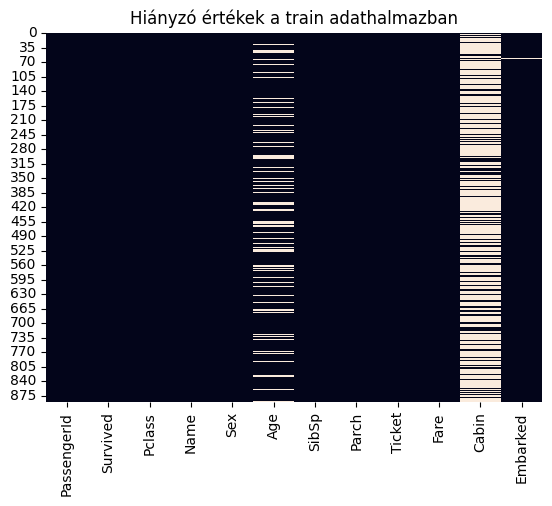

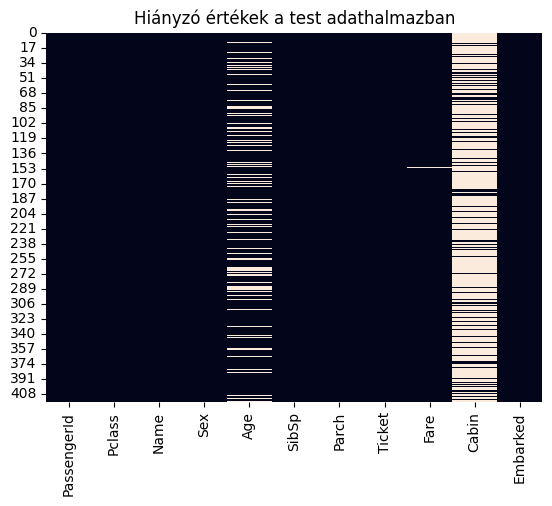

In [37]:
sb.heatmap(train.isnull(), linecolor= "white", cbar=False)
plt.title('Hiányzó értékek a train adathalmazban')
plt.show()

sb.heatmap(test.isnull(), linecolor= "white", cbar=False)
plt.title('Hiányzó értékek a test adathalmazban')
plt.show()

In [38]:
train_new = train.copy()

train_new['Age'] = train_new['Age'].fillna(train_new['Age'].median())

embarked_mode = train_new['Embarked'].mode()[0]
train_new['Embarked'] = train_new['Embarked'].fillna(embarked_mode)

train_new = train_new.drop(columns=['Cabin'])
train_new = train_new.drop(columns=['PassengerId'])

In [39]:
test_new = test.copy()

test_new['Age'] = test_new['Age'].fillna(train_new['Age'].median())
test_new['Fare'] = test_new['Fare'].fillna(train_new['Fare'].median())

test_new['Embarked'] = test_new['Embarked'].fillna(embarked_mode)

test_new = test_new.drop(columns=['Cabin'])
test_new = test_new.drop(columns=['PassengerId'])

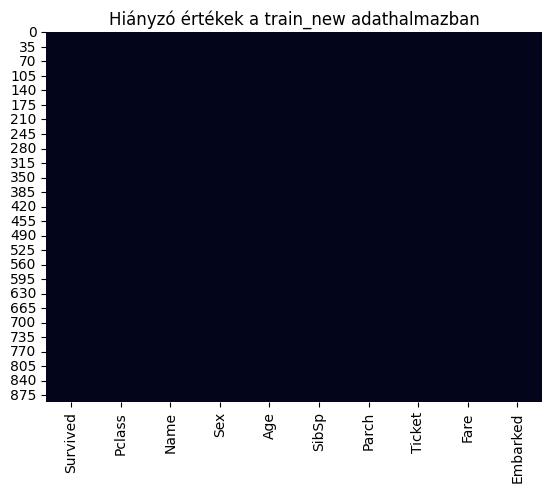

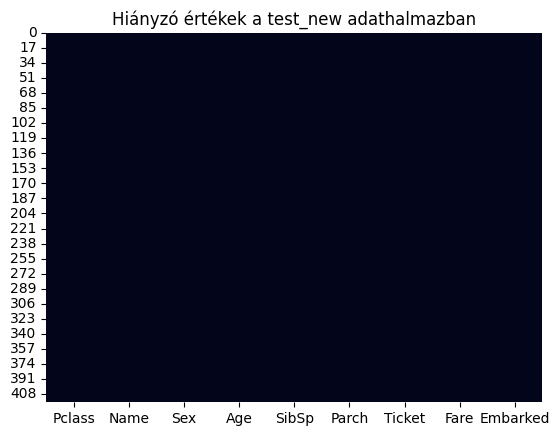

In [40]:
sb.heatmap(train_new.isnull(), linecolor= "white", cbar=False)
plt.title('Hiányzó értékek a train_new adathalmazban')
plt.show()

sb.heatmap(test_new.isnull(), linecolor= "white", cbar=False)
plt.title('Hiányzó értékek a test_new adathalmazban')
plt.show()

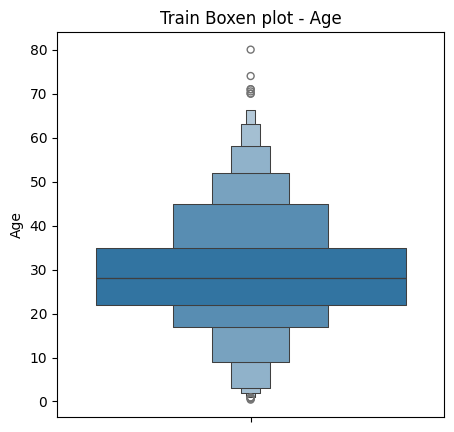

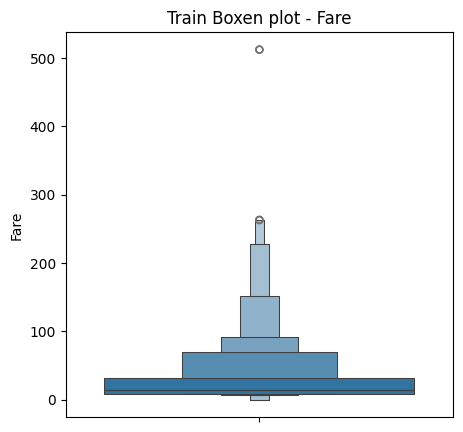

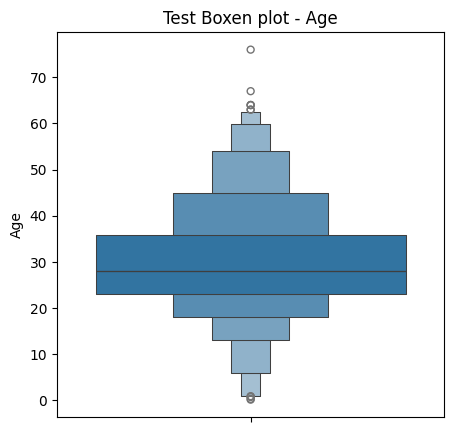

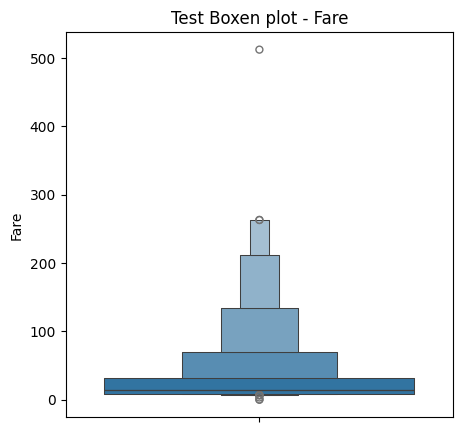

In [41]:
for col in ['Age', 'Fare']:
    plt.figure(figsize=(5,5))
    sb.boxenplot(y=train_new[col])
    plt.title(f'Train Boxen plot - {col}')
    plt.show()

for col in ['Age', 'Fare']:
    plt.figure(figsize=(5,5))
    sb.boxenplot(y=test_new[col])
    plt.title(f'Test Boxen plot - {col}')
    plt.show()

## 3. Feature engineering

In [42]:
train_new['FamilySize'] = train['SibSp'] + train['Parch'] + 1
test_new['FamilySize'] = train['SibSp'] + train['Parch'] + 1

In [43]:
train_new['IsAlone'] = (train_new['FamilySize'] == 1).astype(int)
test_new['IsAlone'] = (test_new['FamilySize'] == 1).astype(int)

In [44]:
train_new['Title'] = train_new['Name'].str.extract(r', (\w+)\.')[0]
test_new['Title'] = test_new['Name'].str.extract(r', (\w+)\.')[0]

In [45]:
train_new = train_new.drop(columns=['Name'])
test_new = test_new.drop(columns=['Name'])

In [46]:
train_new = pd.get_dummies(train_new, columns=['Embarked'], drop_first=False, dtype=int)
test_new = pd.get_dummies(test_new, columns=['Embarked'], drop_first=False, dtype=int)

In [47]:
print(train_new.columns)
print(test_new.columns)

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare',
       'FamilySize', 'IsAlone', 'Title', 'Embarked_C', 'Embarked_Q',
       'Embarked_S'],
      dtype='object')
Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare',
       'FamilySize', 'IsAlone', 'Title', 'Embarked_C', 'Embarked_Q',
       'Embarked_S'],
      dtype='object')


In [50]:
print(train_new.Title.head())

0      Mr
1     Mrs
2    Miss
3     Mrs
4      Mr
Name: Title, dtype: object
